In [80]:
# Data
import pandas as pd
import numpy as np

# Package management
import os
import sys
import importlib

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('white')
sns.set_context("paper")

# Gaussian Processes
import gpflow
gpflow.config.set_default_float(np.float64)
gpflow.config.set_default_summary_fmt("notebook")
f64 = gpflow.utilities.to_default_float # convert to float64 for tfp to play nicely with gpflow

# Tensorflow
import tensorflow as tf
import tensorflow_probability as tfp

# Progress Bars
from tqdm.notebook import tqdm

# Add the parent directory to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))

import ev_forecaster.data.data_processing
import ev_forecaster.models.model
import ev_forecaster.model_utils.mean_function
import ev_forecaster.model_utils.transforms 

importlib.reload(ev_forecaster.data.data_processing)
importlib.reload(ev_forecaster.models.model)
importlib.reload(ev_forecaster.model_utils.mean_function)
importlib.reload(ev_forecaster.model_utils.transforms)

from ev_forecaster.data.data_processing import LSOAVehicleRegistrationDataProcessor, LADVehicleRegistrationDataProcessor
from ev_forecaster.models.model import GPForecastingModel, JointGPForecaster
from ev_forecaster.model_utils.mean_function import CustomMeanFunction, Spline
from ev_forecaster.model_utils.transforms import probit, invprobit

# Loading and Processing Data

### LSOA Registration Data

In [81]:
lsoa_data_processor= LSOAVehicleRegistrationDataProcessor(
    lsoa_lookup_path='../data/lsoa_boundaries/LSOA_(2011)_to_LSOA_(2021)_to_Local_Authority_District_(2022)_Lookup_for_England_and_Wales_(Version_2).csv'
    )
raw_data_path = '../data/lsoa_registrations'
meta_data = {
    'v': {
        'file_name': 'df_VEH0125_2023_Q4.csv',
        'first': 5,
        'last': 57,
        'na_values': ['[c]', '[x]'],
    },
    'ev': {
        'file_name': 'df_VEH0145_2023_Q4.csv',
        'first': 5,
        'last': 56,
        'na_values': ['[c]', '[x]'],
    }
}
filters_dict = {
    'v': {
        'query': "BodyType == 'Cars' and Keepership == 'Private' and LicenceStatus == 'Licensed'",
        'dropped_cols': ['BodyType', 'Keepership', 'LicenceStatus', 'LSOA11NM']
    },
    'ev_private': {
        'query': "Fuel == 'Total' & Keepership == 'Private'",
        'dropped_cols': ['Fuel', 'Keepership', 'LSOA11NM'] 
    },
    'ev_company': {
        'query': "Fuel == 'Total' & Keepership == 'Company'",
        'dropped_cols': ['Fuel', 'Keepership', 'LSOA11NM'] 
    },
    'ev_total': {
        'query': "Fuel == 'Total' & Keepership == 'Total'",
        'dropped_cols': ['Fuel', 'Keepership', 'LSOA11NM'] 
    }
}

lad_list = lsoa_data_processor.lsoa_lookup.LAD22NM.unique()

lsoa_data_processor.load_data(raw_data_path, meta_data)
lsoa_data_processor.filter_data(filters_dict)
lsoa_data_processor.process_data(t_0=2011, t_n=2023)
lad_lsoa_dict = lsoa_data_processor.filter_by_lads(lad_list)

Loading data...
Loading v data from ../data/lsoa_registrations/df_VEH0125_2023_Q4.csv
Loading ev data from ../data/lsoa_registrations/df_VEH0145_2023_Q4.csv
Filtering data...
Processing data...
Filtering data by LADs...


### LAD Registration Data

In [82]:
lad_data_processor = LADVehicleRegistrationDataProcessor()

raw_data_paths = {
    'v' : '../data/lad_registrations/veh0105_2023_Q4.csv',
    'ev' : '../data/lad_registrations/veh0142_2023_Q4.csv',
}

lad_data_processor.load_data(raw_data_paths)

lad_data_processor.process_data(
    query="BodyType == 'Cars' & Fuel == 'Total' & Keepership == 'Private'",
    lad_list=lad_list
)

lad_evms_df = lad_data_processor.lad_evms_df
lad_evms_df

LAD,City of London,Barking and Dagenham,Barnet,Bexley,Brent,Bromley,Camden,Croydon,Ealing,Enfield,...,Bridgend,Vale of Glamorgan,Rhondda Cynon Taf,Caerphilly,Merthyr Tydfil,Cardiff,Newport,Torfaen,Monmouthshire,Blaenau Gwent
2011,0.002000,0.000038,0.000795,0.000052,0.000630,0.000073,0.003007,0.000072,0.000191,0.000091,...,0.000016,0.000000,0.000010,0.000013,0.000000,0.000016,0.000000,0.000000,0.000000,0.000000
2012,0.001333,0.000019,0.000795,0.000083,0.000575,0.000137,0.003171,0.000087,0.000250,0.000082,...,0.000033,0.000033,0.000010,0.000026,0.000000,0.000032,0.000000,0.000000,0.000062,0.000000
2013,0.001333,0.000093,0.001022,0.000124,0.000650,0.000244,0.003725,0.000165,0.000316,0.000208,...,0.000032,0.000083,0.000010,0.000065,0.000088,0.000079,0.000066,0.000000,0.000123,0.000000
2014,0.004000,0.000198,0.001603,0.000162,0.000969,0.000560,0.004595,0.000269,0.000653,0.000394,...,0.000188,0.000261,0.000100,0.000244,0.000128,0.000334,0.000225,0.000169,0.000484,0.000101
2015,0.004667,0.000447,0.002936,0.000379,0.001537,0.001067,0.007020,0.000603,0.001233,0.000825,...,0.000462,0.000774,0.000296,0.000454,0.000084,0.000537,0.000611,0.000357,0.000850,0.000233
2016,0.011333,0.001007,0.004492,0.000809,0.002488,0.001943,0.009800,0.001115,0.001843,0.001189,...,0.000846,0.001413,0.000561,0.000571,0.000163,0.000961,0.001002,0.000609,0.001404,0.000293
2017,0.015000,0.001333,0.006546,0.001535,0.003641,0.003041,0.015038,0.002264,0.003126,0.001904,...,0.001205,0.002324,0.000792,0.000710,0.000484,0.001558,0.001351,0.000966,0.002591,0.000449
2018,0.020000,0.002612,0.009371,0.002606,0.006209,0.004606,0.020359,0.003852,0.004819,0.003383,...,0.001662,0.003181,0.001100,0.001100,0.000873,0.002363,0.001897,0.001219,0.003289,0.000852
2019,0.027857,0.005597,0.013737,0.004090,0.010975,0.006865,0.030654,0.006237,0.009247,0.005915,...,0.002266,0.004380,0.001460,0.001558,0.001167,0.003139,0.002650,0.001545,0.004860,0.000991
2020,0.048462,0.008876,0.020223,0.006528,0.016710,0.010274,0.045288,0.009340,0.013579,0.008923,...,0.003405,0.006293,0.002283,0.002122,0.001875,0.004597,0.003729,0.002406,0.006873,0.001451


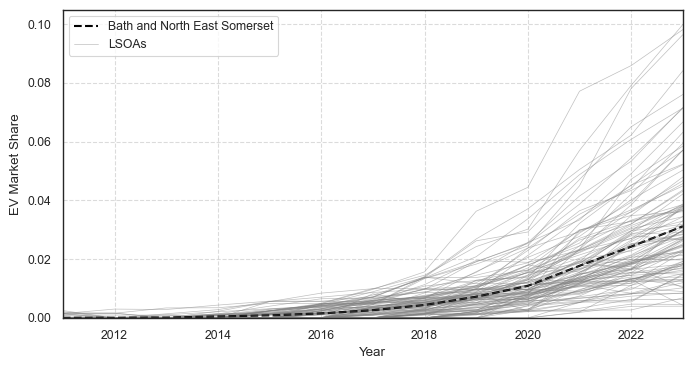

In [83]:
lad = 'Bath and North East Somerset'
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lad_lsoa_dict[lad]['ev_ms'], color='grey', alpha=0.5, lw=0.5)
lad_evms_df[lad].plot(ax=ax, legend=True, color='Black', lw=1.5, linestyle='--')
ax.plot(lad_evms_df[lad], color='grey', alpha=0.5, lw=0.5, label='LSOAs')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('EV Market Share')
plt.xlim(2011, 2023)
plt.ylim(bottom=0)
plt.legend()
plt.show()

# Custom Mean Function

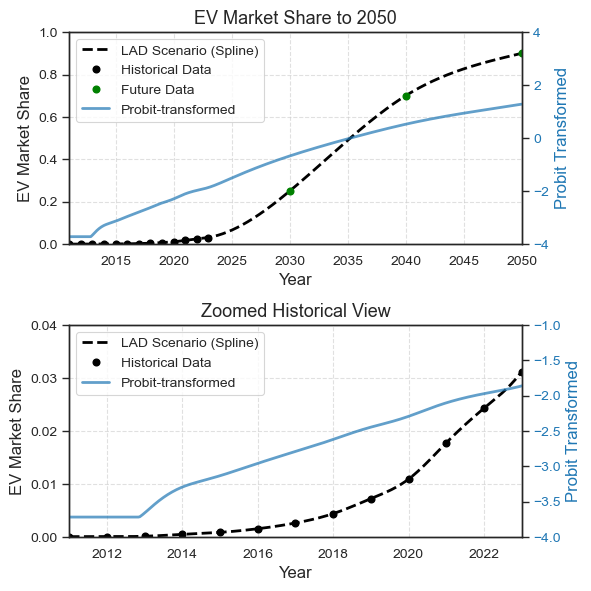

In [84]:
# Example future scenario points
future_points = {
    2030: 0.25,
    2040: 0.7,
    2050: 0.9
}

# LAD to plot
lad = 'Bath and North East Somerset'

# Combine historical and scenario data
lad_ev_ms_df_scenario = pd.concat([lad_evms_df[lad], pd.Series(future_points)])
x = lad_ev_ms_df_scenario.index
y = lad_ev_ms_df_scenario.values

# Fit spline
spl = Spline(x, y)
spl.fit_spline()

# New x-axis values for smooth plotting
x_new = np.linspace(2011, 2050, 1000)
y_spline = spl.evaluate(x_new)
y_probit = probit(y_spline)

# Plot setup
fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharey=False)

# Plot 1: Full range to 2050
ax1 = axes[0]
ax1.plot(x_new, y_spline, '--', color='black', lw=2, label='LAD Scenario (Spline)')
ax1.plot(x[:-3], y[:-3], 'o', color='black', label='Historical Data')
ax1.plot(x[-3:], y[-3:], 'o', color='green', label='Future Data')
ax1.set_xlim(2011, 2050)
ax1.set_ylim(0, 1)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('EV Market Share', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.tick_params(labelsize=10)

# Twin y-axis for probit
ax1b = ax1.twinx()
ax1b.plot(x_new, y_probit, color='C0', lw=2, alpha=0.7, label='Probit-transformed')
ax1b.set_ylabel('Probit Transformed', color='C0', fontsize=12)
ax1b.tick_params(axis='y', labelcolor='C0', labelsize=10)
ax1b.set_ylim(-4, 4)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines1b, labels1b = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines1b, labels1 + labels1b, loc='upper left', fontsize=10)
ax1.set_title('EV Market Share to 2050', fontsize=13)

# Plot 2: Zoomed in to 2023
ax2 = axes[1]
ax2.plot(x_new, y_spline, '--', color='black', lw=2, label='LAD Scenario (Spline)')
ax2.plot(x[:-3], y[:-3], 'o', color='black', label='Historical Data')
ax2.set_xlim(2011, 2023)
ax2.set_ylim(0, 0.04)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('EV Market Share', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.tick_params(labelsize=10)

# Twin y-axis for probit
ax2b = ax2.twinx()
ax2b.plot(x_new, y_probit, color='C0', lw=2, alpha=0.7, label='Probit-transformed')
ax2b.set_ylabel('Probit Transformed', color='C0', fontsize=12)
ax2b.tick_params(axis='y', labelcolor='C0', labelsize=10)
ax2b.set_ylim(-4, -1)

# Legend
lines2, labels2 = ax2.get_legend_handles_labels()
lines2b, labels2b = ax2b.get_legend_handles_labels()
ax2.legend(lines2 + lines2b, labels2 + labels2b, loc='upper left', fontsize=10)
ax2.set_title('Zoomed Historical View', fontsize=13)

plt.tight_layout()
plt.show()

# Example Use of GP Forecasting Model

### Use JointGPForecaster Class

In [85]:
t_dict = {
    't_0': 2011,
    't_n': 2020,
    't_f': 2023
}

joint_gp_forecaster = JointGPForecaster(
    GPForecastingModelClass=GPForecastingModel,
    region='Bath and North East Somerset',
    region_neighbourhood_dict=lad_lsoa_dict,
    region_evms_df=lad_evms_df,
    t_dict=t_dict,
    future_regional_data={
        2030: 0.2,
        2040: 0.7,
        2050: 0.9,
    },
    kernel_prior=gpflow.kernels.RBF(
        lengthscales=gpflow.Parameter(f64(10.0), prior=tfp.distributions.Gamma(f64(10.0), f64(1.0)), transform=tfp.bijectors.Softplus()),
        variance=gpflow.Parameter(f64(0.3), prior=tfp.distributions.Gamma(f64(3.0), f64(10.0)), transform=tfp.bijectors.Softplus())
    ),
    likelihood_prior=gpflow.likelihoods.Gaussian(
        variance=gpflow.Parameter(f64(0.005), prior=tfp.distributions.Gamma(f64(2.0), f64(100.0)), transform=tfp.bijectors.Softplus())
    )
)

joint_gp_forecaster.train()

Summary of optimised hyperparameters

In [86]:
gpflow.utilities.print_summary(joint_gp_forecaster.models[5].gp_model)

name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.variance,Parameter,Softplus,Gamma,True,(),float64,0.118157
GPR.kernel.lengthscales,Parameter,Softplus,Gamma,True,(),float64,5.35248
GPR.likelihood.variance,Parameter,Softplus + Shift,Gamma,True,(),float64,0.00723922


Plotting an example model result

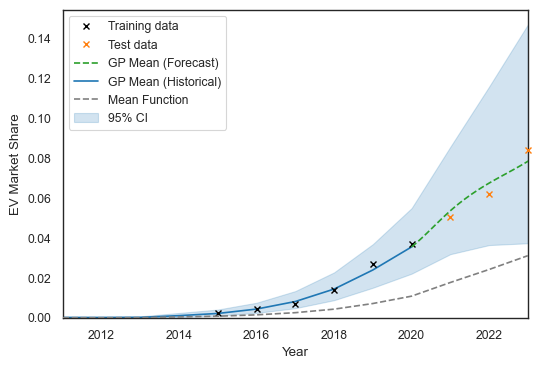

In [87]:
X_new = np.linspace(t_dict['t_n'], t_dict['t_f'] + 1, 100)[:, None].astype(np.float64)
X_plot = np.arange(t_dict['t_0'], t_dict['t_f'] + 1)[:, None]

joint_gp_forecaster.models[5].plot_forecast(
    X_plot=X_plot,
    X_new=X_new,
    probit_transform=False
)